<a href="https://colab.research.google.com/github/soo423/MachineLearning/blob/main/Chapter03_%ED%8F%89%EA%B0%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
#구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

#드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt #그래프를 그리는 모듈
import matplotlib.font_manager as fm # 폰트 관리 모듈

#드라이브 내 폰트 경로
font_path = "/content/drive/MyDrive/Colab_Notebooks/kwu/bigdata/dataPreProcessing/NanumGothic.ttf"

fm.fontManager.addfont(font_path)
mpl.rc('font', family='NanumGothic') #matplotlib 기본 폰트로 설정
plt.rcParams['axes.unicode_minus'] = False #마이너스 기호가 깨지지 않도록 유니코드 마이너스 비활성화

print("현재 폰트: ", plt.rcParams['font.family'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
현재 폰트:  ['NanumGothic']


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, Binarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score
) #분류 모델 평가 지표

import warnings
warnings.filterwarnings('ignore')

In [32]:
diabetes_data = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/kwu/ML/data/diabetes.csv')
print('레이블 분포:')
print(diabetes_data['Outcome'].value_counts())
print(f"당뇨 비율(원본 데이터셋):{diabetes_data['Outcome'].mean()*100:.1f}%")
display(diabetes_data.head(3))

레이블 분포:
Outcome
0    500
1    268
Name: count, dtype: int64
당뇨 비율(원본 데이터셋):34.9%


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [33]:
#전처리 없이 기본 학습/평가
#피처(X) : 마지막 컬럼(Outcome) 제외한 전체
#레이블(y) : 마지막 컬럼(Outcome)
X = diabetes_data.iloc[:, :-1] #'Outcome' 컬럼을 제외한 모든 피처(독립 변수) 선택
y = diabetes_data.iloc[:, -1]  #'Outcome' 컬럼만 레이블 또는 타겟(종속 변수)로 선택
#학습 데이터와 테스트 데이터를 8:2 비율로 분할, y의 클래스 비율을 유지
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=156, stratify=y)

Ir_clf = LogisticRegression(solver='liblinear')#로지스틱 회귀 모델 객체 생성
Ir_clf.fit(X_train, y_train)#학습 데이터로 모델 학습

pred = Ir_clf.predict(X_test) #test 데이터에 대한 에측 레이블 생성
pred_proba = Ir_clf.predict_proba(X_test)[:, 1] #예측 확률[음성, 양성] > 양성(당뇨, 1) 클래스 에측 확률 추출
pred_proba

array([0.04160518, 0.20912837, 0.16482046, 0.51656925, 0.08149191,
       0.69376403, 0.71327173, 0.18558971, 0.18703208, 0.20057413,
       0.62803286, 0.48349546, 0.07639987, 0.34868451, 0.26331384,
       0.14246821, 0.71563568, 0.34133315, 0.03127028, 0.71637019,
       0.35090426, 0.3047434 , 0.07254422, 0.33017374, 0.3006481 ,
       0.1474334 , 0.84947379, 0.65846711, 0.25135397, 0.79328356,
       0.20199844, 0.22273526, 0.17965591, 0.2498647 , 0.17605363,
       0.57951255, 0.28689364, 0.54658369, 0.74887899, 0.6323581 ,
       0.48465258, 0.29961761, 0.59477436, 0.21643951, 0.35035968,
       0.05709475, 0.71563467, 0.13282124, 0.50014795, 0.31771476,
       0.32256529, 0.81031197, 0.83237246, 0.11303412, 0.18887807,
       0.37452468, 0.10650238, 0.38928495, 0.34623632, 0.44244719,
       0.22793794, 0.72712818, 0.31276835, 0.6078356 , 0.27536949,
       0.15379414, 0.22640726, 0.7107828 , 0.19017568, 0.72366567,
       0.12294106, 0.33725937, 0.14888921, 0.45163981, 0.64891

In [50]:
print('전처리 전 로스틱 회귀 성능')
confusion = confusion_matrix(y_test, pred) #오차 행렬 계산
accuracy = accuracy_score(y_test, pred) #정확도 계산
precision = precision_score(y_test, pred) #정밀도 계산
recall = recall_score(y_test, pred) #재현율 계산
f1 = f1_score(y_test, pred) #f1 score 계산
roc_auc = roc_auc_score(y_test, pred_proba) #AUC 계산: 양성 클래스 확률만 사용

print('오차 행렬')
print(confusion)
print('정확도:{0:.4f}, 정밀도:{1:.4f}, 재현율:{2:.4f}, F1:{3:.4f}, AUC:{4:.4f}'.format(
    accuracy, precision, recall, f1, roc_auc))
#정밀도precision: 양성 예측 중 실제 양성 비율
#재현율recall : 실제 양성 중 양성으로 예측한 비율

전처리 전 로스틱 회귀 성능
오차 행렬
[[90 10]
 [21 33]]
정확도:0.7987, 정밀도:0.7674, 재현율:0.6111, F1:0.6804, AUC:0.8433


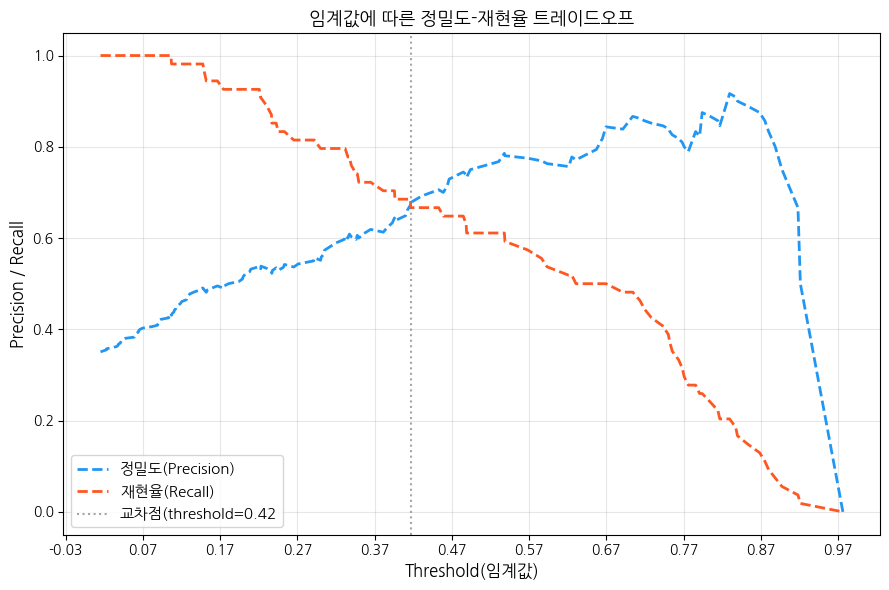

In [52]:
#정밀도-재현율 곡선으로 최적 임계값 탐색
precision, recalls, thresholds = precision_recall_curve(y_test, pred_proba)

plt.figure(figsize=(9, 6))
n = thresholds.shape[0]
plt.plot(thresholds, precision[:n], linestyle='--', label='정밀도(Precision)', color='#2196F3', linewidth=2) #정밀도 곡선 그리기
plt.plot(thresholds, recalls[:n], linestyle='--', label='재현율(Recall)', color='#FF5722', linewidth=2) #재현율 곡선 그리기
cross_idx = np.argmin(np.abs(precision[:n] - recalls[:n]))
plt.axvline(thresholds[cross_idx], color='gray', linestyle=':', alpha=0.7,
            label=f'교차점(threshold={thresholds[cross_idx]:.2f}')
start, end = plt.xlim()
plt.xticks(np.round(np.arange(start, end, 0.1), 2))
plt.xlabel('Threshold(임계값)', fontsize=12)
plt.ylabel('Precision / Recall', fontsize=12)
plt.title('임계값에 따른 정밀도-재현율 트레이드오프', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
#임계값 세밀탐색
thresholds = [0.30, 0.33, 0.36, 0.39, 0.42, 0.45, 0.48, 0.50]
pred_proba = Ir_clf.predict_proba(X_test)[:, 1]

print('임계값별 성능 비교')
for threshold in thresholds:
  binarizer = Binarizer(threshold=threshold).fit(pred_proba.reshape(-1,1))
  pred = binarizer.transform(pred_proba.reshape(-1, 1))
  print(f'\n임계값: {threshold}')
#생성된 예측 레이블과 실제 레이블로 모델 성능 평가(AUC 포함)
  confusion = confusion_matrix(y_test, pred) #오차 행렬 계산
  accuracy = accuracy_score(y_test, pred) #정확도 계산
  precision = precision_score(y_test, pred) #정밀도 계산
  recall = recall_score(y_test, pred) #재현율 계산
  f1 = f1_score(y_test, pred) #f1 score 계산
  roc_auc = roc_auc_score(y_test, pred_proba) #AUC 계산: 양성 클래스 확률만 사용


임계값별 성능 비교

임계값: 0.3

임계값: 0.33

임계값: 0.36

임계값: 0.39

임계값: 0.42

임계값: 0.45

임계값: 0.48

임계값: 0.5


In [38]:
#최적 임계값 : 0.42, 정밀도 0.6852, 재현율 0.6852, f1:0.6852, auc:0.8083
#기본값(0.5)보다 낮음 > 재현율 약간 향상
# 정밀도와 재현율의 균형점

binarizer_final = Binarizer(threshold=0.42)
pred_final = binarizer_final.fit_transform(pred_proba.reshape(-1, 1)) #최종적으로 0 또는 1로 이진화된 예측
print('최적 임계값 적용 최종 평가')

confusion = confusion_matrix(y_test, pred) #오차 행렬 계산
accuracy = accuracy_score(y_test, pred) #정확도 계산
precision = precision_score(y_test, pred) #정밀도 계산
recall = recall_score(y_test, pred) #재현율 계산
f1 = f1_score(y_test, pred) #f1 score 계산
roc_auc = roc_auc_score(y_test, pred_proba) #AUC 계산: 양성 클래스 확률만 사용

print('오차 행렬')
print(confusion)
TN, FP, FN, TP = confusion[0,0], confusion[0,1], confusion[1,0], confusion[1,1]
print(f'\nTN(진음성): {TN} FP(위양성) : {FP})')
print(f'FN(위음성) : {FN} TP(진양성) : {TP}')

최적 임계값 적용 최종 평가
오차 행렬
[[87 13]
 [22 32]]

TN(진음성): 87 FP(위양성) : 13)
FN(위음성) : 22 TP(진양성) : 32


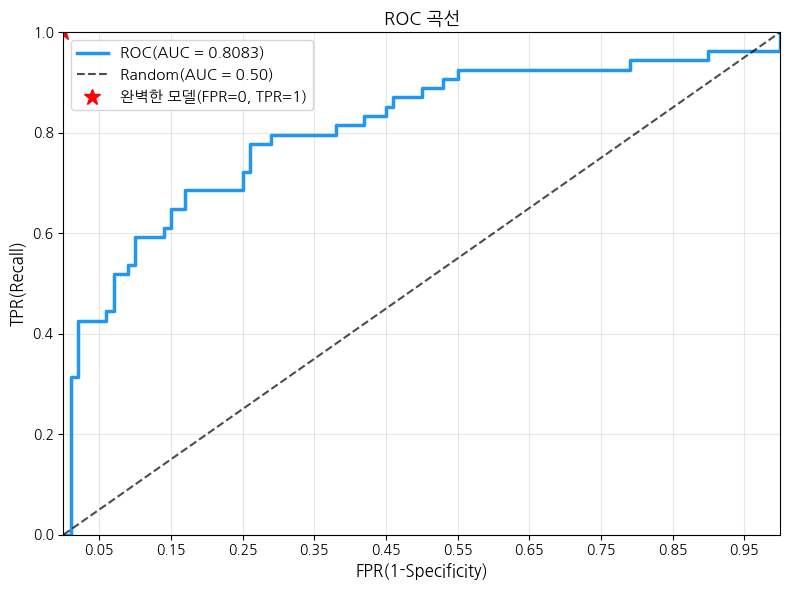

In [39]:
#최종 ROC 곡선 및 AUC 확인
fprs, tprs, _ = roc_curve(y_test, pred_proba) #FRP, TPR 계산, _는 임계값 사용하지 않기에
auc_val = roc_auc_score(y_test, pred_proba) #ROC AUC 값 계산

plt.figure(figsize=(8,6))
plt.plot(fprs, tprs, label=f'ROC(AUC = {auc_val:.4f})', color='#2196F3', linewidth=2.5)
plt.plot([0,1], [0,1], 'k--', label='Random(AUC = 0.50)', linewidth=1.5, alpha=0.7) #(0,0)에서 (1,1)까지 대각선
plt.plot(0, 1, 'r*', markersize=12, label='완벽한 모델(FPR=0, TPR=1)') #완벽한 모델 위치 표시 FPR = 0, TPR= 1

start, end = plt.xlim()
plt.xticks(np.round(np.arange(start, end, 0.1), 2))
plt.xlim(0, 1)#x, y축 범위를 0에서 1로 고정
plt.ylim(0, 1)
plt.xlabel('FPR(1-Specificity)', fontsize=12)
plt.ylabel('TPR(Recall)', fontsize=12)
plt.title('ROC 곡선', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### F1-score 사용 이유
위기 상황을 얼마나 잘 맞추는지 머신러닝 분류(Classification) 문제를 풀 때
*   주차장 만차
*   자전거 부족
*   지하철 매우혼잡



In [40]:
#0값을 가진 피처별 비율 확인
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
total_count = len(diabetes_data)

print('0값이 있는 피처별 건수와 비율:')
for feat in zero_features:
  zero_cnt = (diabetes_data[feat] == 0).sum()
  pct = 100 * zero_cnt / total_count #0값의 비율 계산
  bar = '█' * int(pct // 2)
  print(f' {feat:25}: {zero_cnt:3d}건 ({pct:5.1f}%) {bar}')

0값이 있는 피처별 건수와 비율:
 Glucose                  :   5건 (  0.7%) 
 BloodPressure            :  35건 (  4.6%) ██
 SkinThickness            : 227건 ( 29.6%) ██████████████
 Insulin                  : 374건 ( 48.7%) ████████████████████████
 BMI                      :  11건 (  1.4%) 


In [41]:
#0값 > 평균값 대체
mean_zero = diabetes_data[zero_features].mean() #각 피처의 평균 계산
diabetes_data[zero_features] = diabetes_data[zero_features].replace(0, mean_zero)
zero_after = {f: (diabetes_data[f] == 0 ).sum() for f in zero_features}
print('대체 후 0값 개수:', zero_after)

대체 후 0값 개수: {'Glucose': np.int64(0), 'BloodPressure': np.int64(0), 'SkinThickness': np.int64(0), 'Insulin': np.int64(0), 'BMI': np.int64(0)}


In [43]:
#의학 데이터에서 혈당, 혈압 등이 0이면 측정 불가 = 결측치
print('기술통계:')
display(diabetes_data.describe())

기술통계:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.681605,72.254807,26.606479,118.660163,32.450805,0.471876,33.240885,0.348958
std,3.369578,30.436016,12.115932,9.631241,93.080358,6.875374,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,20.536458,79.799479,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,79.799479,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [44]:
#전처리
#피처(X) : 마지막 컬럼(Outcome) 제외한 전체
#레이블(y) : 마지막 컬럼(Outcome)
X = diabetes_data.iloc[:, :-1] #'Outcome' 컬럼을 제외한 모든 피처(독립 변수) 선택
y = diabetes_data.iloc[:, -1]  #'Outcome' 컬럼만 레이블 또는 타겟(종속 변수)로 선택

#표준화 : 모든 피처를 평균 = 0, 표준편차=1로 변환
#로지스틱 회귀는 스케일에 민감하므로 표준화 후 성능 향상
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X) #

#train 데이터와 test 데이터를 8:2 비율로 분할, y의 클래스 비율을 유지
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=156, stratify=y)

Ir_clf = LogisticRegression(solver='liblinear')#로지스틱 회귀 모델 객체 생성
Ir_clf.fit(X_train, y_train)#학습 데이터로 모델 학습

pred = Ir_clf.predict(X_test) #test 데이터에 대한 에측 레이블 생성
pred_proba = Ir_clf.predict_proba(X_test)[:, 1] #예측 확률[음성, 양성] > 양성(당뇨, 1) 클래스 에측 확률 추출
pred_proba

array([0.03609018, 0.20217293, 0.15928588, 0.5681113 , 0.41651923,
       0.75549138, 0.83987164, 0.15198534, 0.19444674, 0.1077338 ,
       0.66955827, 0.39625109, 0.04715651, 0.39291971, 0.26530665,
       0.09318057, 0.79415787, 0.08938344, 0.5860422 , 0.80457251,
       0.41814913, 0.34954916, 0.06452018, 0.3194815 , 0.30000267,
       0.10537022, 0.92130861, 0.75027822, 0.17419735, 0.88879611,
       0.23061778, 0.23754691, 0.11313996, 0.15306837, 0.10329326,
       0.74313694, 0.2224308 , 0.20825111, 0.85342706, 0.66495884,
       0.41219643, 0.23686881, 0.70419015, 0.13055228, 0.34605328,
       0.0150281 , 0.46644956, 0.08887057, 0.48910823, 0.33082282,
       0.31213555, 0.91820103, 0.89749958, 0.06165143, 0.12671445,
       0.43108455, 0.07021933, 0.35552394, 0.3317995 , 0.39565923,
       0.18076256, 0.83760011, 0.33534618, 0.62537857, 0.3051479 ,
       0.1038554 , 0.24510902, 0.7193746 , 0.14750218, 0.77086348,
       0.06017212, 0.33727392, 0.12026259, 0.45894577, 0.79087